### Deep learning clasification model

In [12]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, jaccard_score, confusion_matrix, cohen_kappa_score
import seaborn as sns

from io import BytesIO
from openpyxl.drawing.image import Image

import json

In [13]:
with open("../data/enviroment_bbox.json", "r") as f:
    bbox = json.load(f)

enviroment_bbox = [
    bbox["min_lon"],
    bbox["min_lat"],
    bbox["max_lon"],
    bbox["max_lat"]
]

In [ ]:
dry_run = False
todas = False
save = False
sp = "SQA"
features = ["TO", #"SO", "TOB", 
            "MLOTST", "UGO", "VGO", #"ZO",
            #"CHL", "PP", #"CDM", "SPM", "ZSD"
            "MSEN", "MCOS", #"Año",
            ]

horizon = 1
lead=6

from dataset_loader import DataBuilder
data_builder = DataBuilder(target_var="CPUE_class_q30", sp=sp, features=features,
                           prediction_horizon=horizon, forecast_lead=lead, window_size=12,
                           start_date="2012-01-01", end_date="2025-12-31",
                            enviroment_bbox=enviroment_bbox, split_year=2024, split_year_test=2025,
                            )

# Fetch the DataLoaders
train_loader, val_loader, test_loader = data_builder.get_loaders()
in_channels = data_builder.in_channels
out_hw = data_builder.out_hw

Loading and aligning dataset...
Preprocessing and scaling...
Creating rolling windows...
Train: X torch.Size([144, 12, 6, 54, 49]) | y torch.Size([144, 1, 30, 17])
Val:   X torch.Size([12, 12, 6, 54, 49]) | y torch.Size([12, 1, 30, 17])
Test:  X torch.Size([12, 12, 6, 54, 49]) | y torch.Size([12, 1, 30, 17])


In [15]:
class CESpatialLoss(nn.Module):
    def __init__(self, window_size=11):
        super().__init__()
        self.window_size = window_size
        self.register_buffer("window", torch.ones(1, 1, window_size, window_size) / (window_size ** 2))

    def forward(self, pred, target, mask, weights=None, ssim_weight=0.5):
        """
        pred:    (B, C, horizon, H, W)
        target:  (B, horizon, H, W)
        mask:    (B, horizon, H, W)
        weights: (C,)
        """
        B, C, horizon, H, W = pred.shape

        target = target.long()
        mask_float = mask.float()

        # Treat each prediction horizon as an independent classification map
        pred_2d = pred.permute(0, 2, 1, 3, 4).reshape(B * horizon, C, H, W)
        target_2d = target.reshape(B * horizon, H, W)
        mask_2d = mask_float.reshape(B * horizon, H, W)

        # 1. Masked Cross-Entropy
        ce_loss = F.cross_entropy(pred_2d, target_2d, weight=weights, reduction='none')
        masked_ce = (ce_loss * mask_2d).sum() / (mask_2d.sum() + 1e-8)

        # 2. Masked SSIM
        ssim_loss = self._differentiable_ssim(pred_2d, target_2d, mask_2d)

        return masked_ce + ssim_weight * ssim_loss

    def _differentiable_ssim(self, pred, target, mask):
        B, C, H, W = pred.shape

        probs = F.softmax(pred, dim=1)
        target_oh = F.one_hot(target, num_classes=C).permute(0, 3, 1, 2).float()

        probs = probs.reshape(B * C, 1, H, W)
        target_oh = target_oh.reshape(B * C, 1, H, W)
        mask_expanded = mask.unsqueeze(1).repeat(1, C, 1, 1).reshape(B * C, 1, H, W)

        data_range = 1.0
        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2
        pad = self.window_size // 2

        mu1 = F.conv2d(probs, self.window, padding=pad)[:, :, :H, :W]
        mu2 = F.conv2d(target_oh, self.window, padding=pad)[:, :, :H, :W]

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        sigma1_sq = F.conv2d(probs * probs, self.window, padding=pad)[:, :, :H, :W] - mu1_sq
        sigma2_sq = F.conv2d(target_oh * target_oh, self.window, padding=pad)[:, :, :H, :W] - mu2_sq
        sigma12 = F.conv2d(probs * target_oh, self.window, padding=pad)[:, :, :H, :W] - mu1_mu2

        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

        masked_ssim = (ssim_map * mask_expanded).sum() / (mask_expanded.sum() + 1e-8)

        return 1.0 - masked_ssim

In [16]:
def compute_metrics_multiclass(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),

        # Class 1
        "precision_1": precision_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),
        "recall_1": recall_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),
        "f1_1": f1_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),

        # Class 2
        "precision_2": precision_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
        "recall_2": recall_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
        "f1_2": f1_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
    }

In [17]:
from modelos_DL import UNet3DCla

iters = 2
list_of_F1_train = []
list_of_F1_val = []
list_of_train_loss = []
list_of_val_loss = []

for i in range(iters):

    print(f"----------------------------------------------------Iteration {i+1}/{iters}-----------------------------------------------------------------------")

    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UNet3DCla(in_channels=in_channels, out_hw=out_hw, num_classes=3, base_ch=12, prediction_horizon=data_builder.prediction_horizon).to(device)
    model_name = model.__class__.__name__
    if dry_run:
        print("no run")
        break
    best_model_path = f"./modelos/runs/Classification/{model_name}_{sp}_{i+1}.pth"
    if todas:
        best_model_path = f"./modelos/runs/Classification/{model_name}_{sp}_{i+1}_todas.pth"

    loss_func = CESpatialLoss(window_size=7).to(device) 

    optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=30)
    weights = torch.tensor([1.0, 1.1, 1.1]).to(device)

    best_val_f1 = -float("inf")
    patience = 20    
    counter = 0
    epochs = 200

    train_f1_history = []
    val_f1_history = []
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()

        train_preds = []
        train_trues = []
        total_loss = 0

        # Unpack x, y, and mask (m)
        for x, y, m in train_loader:

            x = x.to(device)
            y = y.to(device)  # (B, horizon, H, W)
            m = m.to(device)  # (B, horizon, H, W)

            optimizer.zero_grad()

            logits = model(x)  # (B,horizon,H,W)
            loss = loss_func(logits, y, mask=m, weights=weights, ssim_weight=1.5)

            loss.backward()
            optimizer.step()

            total_loss += loss.detach()

            preds = torch.softmax(logits, dim=1).argmax(dim=1)

            # Filter predictions and targets using the mask
            # Converting mask to boolean creates a 1D tensor of only the valid pixels
            m_bool = m.bool()
            
            valid_preds = preds[m_bool]
            valid_trues = y[m_bool]

            train_preds.append(valid_preds.detach().cpu().numpy())
            train_trues.append(valid_trues.detach().cpu().numpy())

        epoch_train_loss = (total_loss / len(train_loader)).cpu().item()
        train_loss_history.append(epoch_train_loss)

        y_true = np.concatenate(train_trues)
        y_pred = np.concatenate(train_preds)

        train_metrics = compute_metrics_multiclass(y_true, y_pred)
        train_f1 = (train_metrics["f1_1"] + train_metrics["f1_2"]) / 2

        # ---------------- VALIDATION ----------------
        model.eval()

        val_preds = []
        val_trues = []
        total_val_loss = 0.0
        with torch.no_grad():
            for x, y, m in val_loader:

                x = x.to(device)
                y = y.to(device)
                m = m.to(device)
                m_bool = m.bool()

                logits = model(x)
                loss = loss_func(logits, y, m, weights=weights, ssim_weight=1.5)
                total_val_loss += loss.detach()

                preds = torch.softmax(logits, dim=1).argmax(dim=1)
                
                valid_preds = preds[m_bool]
                valid_trues = y[m_bool]

                val_preds.append(valid_preds.cpu().numpy())
                val_trues.append(valid_trues.cpu().numpy())
        epoch_val_loss = (total_val_loss / len(val_loader)).cpu().item()
        val_loss_history.append(epoch_val_loss)
        y_true_val = np.concatenate(val_trues)
        y_pred_val = np.concatenate(val_preds)

        val_metrics = compute_metrics_multiclass(y_true_val, y_pred_val)

        # val_f1 = (val_metrics["f1_1"] + val_metrics["f1_2"]) / 2  # Focus on both classes
        val_f1 = val_metrics["f1_2"]  # Focus on class 2 for early stopping

        # ---------------- EARLY STOPPING ----------------
        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            counter = 0
            torch.save(model.state_dict(), best_model_path)
            print("Saved")
        else:
            if best_val_f1>0:
                counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

        print(
            f"{epoch+1}/{epochs} | "
            f"Loss: {total_loss/len(train_loader):.3f} | "
            f"Train F1: {train_f1:.3f} | "
            f"Val F1: {val_f1:.3f} | "
            f"Best F1: {best_val_f1:.3f} | "
            f"F1_1: {val_metrics['f1_1']:.3f} | "
            f"F1_2: {val_metrics['f1_2']:.3f} | "
            f"p1: {val_metrics['precision_1']:.3f} r1: {val_metrics['recall_1']:.3f} | "
            f"p2: {val_metrics['precision_2']:.3f} r2: {val_metrics['recall_2']:.3f}"
        )

        train_f1_history.append(train_f1)
        val_f1_history.append(val_f1)

    list_of_train_loss.append(train_loss_history)
    list_of_val_loss.append(val_loss_history)
    list_of_F1_train.append(train_f1_history)
    list_of_F1_val.append(val_f1_history)





----------------------------------------------------Iteration 1/2-----------------------------------------------------------------------
Saved
1/200 | Loss: 2.565 | Train F1: 0.203 | Val F1: 0.000 | Best F1: 0.000 | F1_1: 0.361 | F1_2: 0.000 | p1: 0.220 r1: 1.000 | p2: 0.000 r2: 0.000
2/200 | Loss: 2.440 | Train F1: 0.198 | Val F1: 0.000 | Best F1: 0.000 | F1_1: 0.361 | F1_2: 0.000 | p1: 0.220 r1: 1.000 | p2: 0.000 r2: 0.000
3/200 | Loss: 2.356 | Train F1: 0.221 | Val F1: 0.000 | Best F1: 0.000 | F1_1: 0.369 | F1_2: 0.000 | p1: 0.228 r1: 0.973 | p2: 0.000 r2: 0.000
4/200 | Loss: 2.288 | Train F1: 0.234 | Val F1: 0.000 | Best F1: 0.000 | F1_1: 0.439 | F1_2: 0.000 | p1: 0.296 r1: 0.845 | p2: 0.000 r2: 0.000
5/200 | Loss: 2.211 | Train F1: 0.232 | Val F1: 0.000 | Best F1: 0.000 | F1_1: 0.473 | F1_2: 0.000 | p1: 0.354 r1: 0.712 | p2: 0.000 r2: 0.000
6/200 | Loss: 2.163 | Train F1: 0.249 | Val F1: 0.000 | Best F1: 0.000 | F1_1: 0.501 | F1_2: 0.000 | p1: 0.413 r1: 0.636 | p2: 0.000 r2: 0.000

In [18]:
file_name = f"./modelos/runs/Classification/tloop_{model_name}_{sp}.json"
if todas:
    file_name = f"./modelos/runs/Classification/tloop_{model_name}_{sp}_todas.json"
if not dry_run:
    data = {
        "list_of_F1_train": list_of_F1_train,
        "list_of_F1_val": list_of_F1_val,
        "list_of_train_loss": list_of_train_loss,
        "list_of_val_loss": list_of_val_loss
    }

    with open(file_name, "w") as file:
        json.dump(data, file, indent=2)

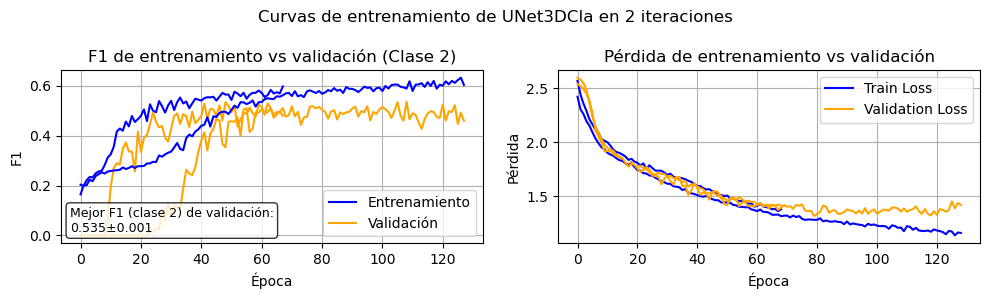

0

In [19]:
with open(file_name, "r") as file:
    data = json.load(file)
list_of_F1_train = data["list_of_F1_train"]
list_of_F1_val = data["list_of_F1_val"]
list_of_train_loss = data["list_of_train_loss"]
list_of_val_loss = data["list_of_val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle(f"Curvas de entrenamiento de {model_name} en {iters} iteraciones", fontsize=12)
for i in range(len(list_of_F1_train) - 1):
    axes[0].plot(list_of_F1_train[i], color="blue")
    axes[0].plot(list_of_F1_val[i], color="orange")
axes[0].plot(list_of_F1_train[-1], color="blue", label="Entrenamiento")
axes[0].plot(list_of_F1_val[-1], color="orange", label="Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("F1")
axes[0].set_title("F1 de entrenamiento vs validación (Clase 2)")
axes[0].grid(True)
axes[0].legend()

for i in range(len(list_of_train_loss) - 1):
    axes[1].plot(list_of_train_loss[i], color="blue")
    axes[1].plot(list_of_val_loss[i], color="orange")
axes[1].plot(list_of_train_loss[-1], color="blue", label="Train Loss")
axes[1].plot(list_of_val_loss[-1], color="orange", label="Validation Loss")

axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].set_title("Pérdida de entrenamiento vs validación")
axes[1].grid(True)
axes[1].legend()

best_val_F1 = np.array([np.max(f1_curve) for f1_curve in list_of_F1_val])
mean_best_val_F1 = best_val_F1.mean()
std_best_val_F1 = best_val_F1.std()
# Text annotation inside the plot
axes[0].text(
    0.02,
    0.05,
    f"Mejor F1 (clase 2) de validación:\n{mean_best_val_F1:.3f}±{std_best_val_F1:.3f}",
    transform=axes[0].transAxes,
    fontsize=9,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)

In [20]:
def compute_metrics(preds, targets, mask_spatial=None):

    # =====================================================
    # 1. OVERALL CLASSIFICATION METRICS
    # =====================================================
    if mask_spatial is not None:
        mask_bool = mask_spatial.astype(bool)
        y_true_flat = targets[mask_bool].astype(int)
        y_pred_flat = preds[mask_bool].astype(int)
    else:
        valid_idx = ~np.isnan(targets) & ~np.isnan(preds)
        y_true_flat = targets[valid_idx].astype(int)
        y_pred_flat = preds[valid_idx].astype(int)

    report = pd.DataFrame(classification_report(y_true_flat, y_pred_flat, output_dict=True, labels=[0, 1, 2], zero_division=0)).T
    iou_per_class = jaccard_score(y_true_flat, y_pred_flat, average=None, labels=[0, 1, 2], zero_division=0)
    kappa = cohen_kappa_score(y_true_flat, y_pred_flat)

    # =====================================================
    # 2. CONFUSION MATRIX
    # =====================================================
    class_labels = ['Nada (0)', 'CPUE bajo (1)', 'CPUE alto (2)']
    cm = pd.DataFrame(confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1, 2]), index=class_labels, columns=class_labels)

    # =====================================================
    # 3. F1 CLASS 2 BY PREDICTION HORIZON
    # =====================================================
    print("\nF1 class 2 by prediction horizon")

    for h in range(targets.shape[1]):
        if mask_spatial is not None:
            mask_h = mask_spatial[:, h].astype(bool)
            y_true_h = targets[:, h][mask_h].astype(int)
            y_pred_h = preds[:, h][mask_h].astype(int)
        else:
            valid_h = ~np.isnan(targets[:, h]) & ~np.isnan(preds[:, h])
            y_true_h = targets[:, h][valid_h].astype(int)
            y_pred_h = preds[:, h][valid_h].astype(int)

        f1_h = f1_score(y_true_h, y_pred_h, labels=[2], average=None, zero_division=0)[0]
        print(f"Month +{h+1}: F1 class 2 = {f1_h:.4f} ({len(y_true_h)},)")

    return report, iou_per_class, kappa, cm

In [21]:
reports = []
ious = []
kappas = []
confusion_matrices = []

for i in range(iters):
    print(f"Iteration {i+1}/{iters}")

    model_path = f"./modelos/runs/Classification/{model_name}_{sp}_{i+1}.pth"
    if todas:
        model_path = f"./modelos/runs/Classification/{model_name}_{sp}_{i+1}_todas.pth"

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_targets = []
    all_masks = []

    with torch.no_grad():
        for x, y, m in test_loader:
            x = x.to(device)

            logits = model(x)                  # (B, classes, horizon, H, W)
            pred = logits.argmax(dim=1)        # (B, horizon, H, W)

            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.numpy())
            all_masks.append(m.numpy())

    preds_all = np.concatenate(all_preds, axis=0)
    targets_all = np.concatenate(all_targets, axis=0)
    masks_all = np.concatenate(all_masks, axis=0)

    print("Predictions:", preds_all.shape)
    print("Targets:", targets_all.shape)
    print("Masks:", masks_all.shape)

    report, iou_per_class, kappa, cm = compute_metrics(preds_all, targets_all, masks_all)

    reports.append(report)
    ious.append(iou_per_class)
    kappas.append(kappa)
    confusion_matrices.append(cm)

    print(report)




Iteration 1/2
Predictions: (12, 1, 30, 17)
Targets: (12, 1, 30, 17)
Masks: (12, 1, 30, 17)

F1 class 2 by prediction horizon
Month +1: F1 class 2 = 0.6271 (1500,)
              precision    recall  f1-score      support
0              0.830059  0.914502  0.870237   924.000000
1              0.775568  0.677419  0.723179   403.000000
2              0.730769  0.549133  0.627063   173.000000
accuracy       0.808667  0.808667  0.808667     0.808667
macro avg      0.778799  0.713685  0.740159  1500.000000
weighted avg   0.803968  0.808667  0.802681  1500.000000
Iteration 2/2
Predictions: (12, 1, 30, 17)
Targets: (12, 1, 30, 17)
Masks: (12, 1, 30, 17)

F1 class 2 by prediction horizon
Month +1: F1 class 2 = 0.5984 (1500,)
              precision    recall  f1-score      support
0              0.871145  0.856061  0.863537   924.000000
1              0.728426  0.712159  0.720201   403.000000
2              0.560606  0.641618  0.598383   173.000000
accuracy       0.792667  0.792667  0.792667    

,IoU
Clase 0,0.765±0.007
Clase 1,0.565±0.003
Clase 2,0.442±0.021


,Mean ± Std
Cohen's Kappa,0.621±0.005


,precision,recall,f1-score,support
0,0.851±0.029,0.885±0.041,0.867±0.005,924.000±0.000
1,0.752±0.033,0.695±0.025,0.722±0.002,403.000±0.000
2,0.646±0.120,0.595±0.065,0.613±0.020,173.000±0.000
accuracy,0.801±0.011,0.801±0.011,0.801±0.011,0.801±0.011
macro avg,0.749±0.042,0.725±0.016,0.734±0.009,1500.000±0.000
weighted avg,0.800±0.005,0.801±0.011,0.799±0.006,1500.000±0.000


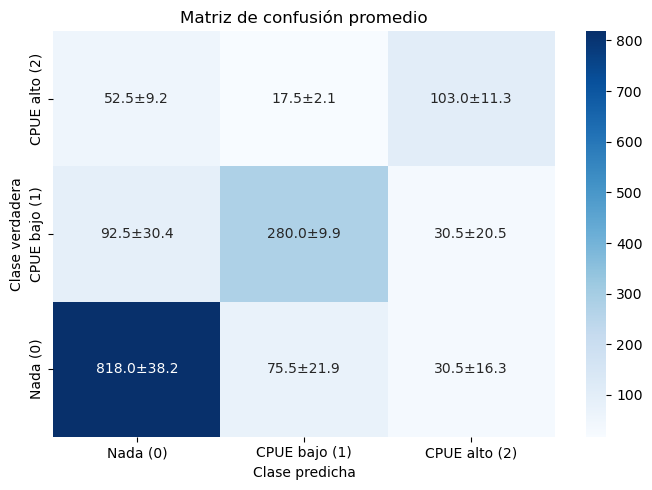

NameError: name 'save' is not defined

In [22]:
#get summary statistics and save

ious_df = pd.DataFrame(ious, columns=["Clase 0", "Clase 1", "Clase 2"])
iou_mean_std = pd.DataFrame({
    "IoU": ious_df.apply(
        lambda x: f"{x.mean():.3f}±{x.std():.3f}"
    )
})

display(iou_mean_std)

metrics_df = pd.DataFrame({
    "Cohen's Kappa": kappas,
})

metrics_mean_std = pd.DataFrame({
    "Mean ± Std": metrics_df.apply(
        lambda x: f"{x.mean():.3f}±{x.std():.3f}"
    )
})

display(metrics_mean_std)

report_mean_std = (
    pd.concat(reports, keys=range(len(reports)))
    .groupby(level=1)
    .agg(lambda x: f"{x.mean():.3f}±{x.std():.3f}")
)

display(report_mean_std)

cm_mean = (
    pd.concat(confusion_matrices, keys=range(len(confusion_matrices)))
    .groupby(level=1)
    .mean()
)

cm_std = (
    pd.concat(confusion_matrices, keys=range(len(confusion_matrices)))
    .groupby(level=1)
    .std()
)

cm_annotations = cm_mean.combine(
    cm_std,
    lambda mean, std: mean.map(lambda x: f"{x:.1f}")
                      + "±"
                      + std.map(lambda x: f"{x:.1f}")
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_mean, annot=cm_annotations, fmt="", cmap="Blues", xticklabels=cm_mean.columns,yticklabels=cm_mean.index)

plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión promedio")
plt.tight_layout()
img_buffer3 = BytesIO()
plt.savefig(img_buffer3, format="png", bbox_inches="tight")
img_buffer3.seek(0)

plt.show()


#save to excel
# save everyhtng to a excel workbook
if save:
    sheet_name = f"{model_name}_{sp}+{lead}"
    if todas:
        sheet_name = f"{model_name}_{sp}_todas"
    with pd.ExcelWriter("./modelos/resultados/Class/DL_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    
        report_mean_std.to_excel(writer, sheet_name=sheet_name, startrow=1)

    with pd.ExcelWriter("./modelos/resultados/Class/DL_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:

        iou_mean_std.to_excel(writer, sheet_name=sheet_name, startrow=len(report_mean_std) + 3)
        metrics_mean_std.to_excel(writer, sheet_name=sheet_name, startrow=len(report_mean_std) + len(iou_mean_std) + 6, index=False)
        ws = writer.sheets[sheet_name]
        img1 = Image(img_buffer1)
        ws.add_image(img1, f"N1")
        img3 = Image(img_buffer3)
        ws.add_image(img3, f"N41")